In [19]:
# Load Libraries
import pandas as pd
from census import Census
from us import states
import numpy as np
import requests
import pandas as pd
import time

In [20]:
# Census Data

# 1. Initialize with your API Key
# Replace 'YOUR_KEY_HERE' with your actual Census API Key
c = Census("0227320b3ac4bfe65e4c7427ed8665c2244b2fb3")

# 2. Define the variables you want to pull (ACS 5-Year Estimates)
# B01003_001E: Total Population
# B19013_001E: Median Household Income
# B15003_022E: Bachelor's Degrees (Age 25+)
# B01002_001E: Median Age
variables = ('NAME', 'B01003_001E', 'B19013_001E', 'B15003_022E', 'B01002_001E')

# 3. Pull the data
# We query ZCTAs (Zip Code Tabulation Areas)
print("Fetching data from Census Bureau...")
results = c.acs5.get(variables, {'for': 'zip code tabulation area:*'})

# 4. Convert to DataFrame and Clean
df = pd.DataFrame(results)
df.rename(columns={
    'B01003_001E': 'total_pop',
    'B19013_001E': 'median_income',
    'B15003_022E': 'bachelors_degrees',
    'B01002_001E': 'median_age',
    'zip code tabulation area': 'zip_code'
}, inplace=True)

# 5. Filter for Utah Zip Codes (Utah zips typically start with 84xxx)
# For a more precise filter, you can provide a specific list of Utah zips
utah_df = df[df['zip_code'].str.startswith('84')].copy()

# 6. Basic Feature Engineering: % with Bachelor's Degree
utah_df['pct_bachelors'] = (utah_df['bachelors_degrees'].astype(float) / 
                            utah_df['total_pop'].astype(float)) * 100

print(f"Success! Retrieved data for {len(utah_df)} Utah zip codes.")
print(utah_df.head())

# Save to CSV for your project
# utah_df.to_csv('utah_fitness_demographics.csv', index=False)

Fetching data from Census Bureau...
Success! Retrieved data for 298 Utah zip codes.
              NAME  total_pop  median_income  bachelors_degrees  median_age  \
29328  ZCTA5 84001      661.0        67375.0               34.0        27.4   
29329  ZCTA5 84002      306.0        43125.0               13.0        30.6   
29330  ZCTA5 84003    55259.0       120262.0            10436.0        27.5   
29331  ZCTA5 84004    10272.0       156786.0             2231.0        36.7   
29332  ZCTA5 84005    49116.0       105576.0             6362.0        22.0   

      zip_code  pct_bachelors  
29328    84001       5.143722  
29329    84002       4.248366  
29330    84003      18.885611  
29331    84004      21.719237  
29332    84005      12.953009  


In [21]:
# Clean up census df
utah_df.replace(-666666666, np.nan, inplace=True)

utah_df = utah_df.dropna(subset=['total_pop', 'median_income'])

utah_df = utah_df[utah_df['total_pop'] > 0]

In [22]:
# preview

utah_df.head()

,NAME,total_pop,median_income,bachelors_degrees,median_age,zip_code,pct_bachelors
29328,ZCTA5 84001,661.0,67375.0,34.0,27.4,84001,5.143722
29329,ZCTA5 84002,306.0,43125.0,13.0,30.6,84002,4.248366
29330,ZCTA5 84003,55259.0,120262.0,10436.0,27.5,84003,18.885611
29331,ZCTA5 84004,10272.0,156786.0,2231.0,36.7,84004,21.719237
29332,ZCTA5 84005,49116.0,105576.0,6362.0,22.0,84005,12.953009


In [23]:
# Yelp DF

API_KEY = 'vwVDFljHUMs6UCKeSs-EaLRynI7cTmvGSTXEBRn6PdTApVWT5w1DpW1EFWFobl5FDgNfQ6t3T43e6j3GInTe_v9mkSNz7NRMPJxL4uVsegh8Fl-CBtk9PomtEyvIaXYx'
HEADERS = {'Authorization': f'Bearer {API_KEY}'}
ENDPOINT = 'https://api.yelp.com/v3/businesses/search'

def get_gyms_for_zip(zip_code):
    params = {
        'categories': 'gyms,yoga,pilates,healthtrainers,martialarts',
        'location': f'{zip_code}, Utah',
        'limit': 50 
    }
    
    response = requests.get(ENDPOINT, headers=HEADERS, params=params)
    
    if response.status_code == 200:
        return response.json()['businesses']
    else:
        print(f"Error for zip {zip_code}: {response.status_code}")
        return []


sample_zip = "84604" 
raw_data = get_gyms_for_zip(sample_zip)

gym_list = []
for biz in raw_data:
    # --- CRITICAL: Define these variables inside the loop first ---
    # Gets the first category alias (like 'yoga')
    main_cat = biz['categories'][0]['alias'] if biz.get('categories') else 'unknown'
    
    # Checks if they have any special services
    services = 1 if biz.get('transactions') else 0
    # -----------------------------------------------------------

    gym_list.append({
        'name': biz['name'],
        'zip_code': biz['location']['zip_code'],
        'latitude': biz['coordinates']['latitude'],
        'longitude': biz['coordinates']['longitude'],
        'rating': biz['rating'],
        'review_count': biz['review_count'],
        'category': main_cat,
        'distance': biz.get('distance')
    })

gyms_df = pd.DataFrame(gym_list)
print(gyms_df.head())

                          name zip_code   latitude   longitude  rating  \
0                   The Quarry    84604  40.264905 -111.669741     4.3   
1                      3B Yoga    84604  40.298546 -111.658005     5.0   
2                   Bodhi Yoga    84604  40.259344 -111.664415     5.0   
3       Embody Wellness Center    84058  40.275410 -111.688706     4.9   
4  InBalance Wellness and Yoga    84057  40.313432 -111.707028     5.0   

   review_count         category      distance  
0            22    rock_climbing  12833.275485  
1            13             yoga   9522.678218  
2             7             yoga  13231.452336  
3             9  massage_therapy  13183.002659  
4            10             yoga  12073.777764  


note: The Distance: This is the actual distance (in meters) from the center of the Zip Code. It tells you if the gym is in the "heart" of the commercial district or on the outskirts.

In [24]:
# investigating price = 'none' for majority of fitness businesses

# 1. Calculate the number of missing values per column
missing_counts = gyms_df.isnull().sum()

# 2. Calculate the percentage of missing values per column
missing_pct = (gyms_df.isnull().sum() / len(gyms_df)) * 100

# 3. Combine into a nice summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

print("--- Missing Data Summary ---")
print(missing_summary)

--- Missing Data Summary ---
              Missing Count  Percentage (%)
name                      0             0.0
zip_code                  0             0.0
latitude                  0             0.0
longitude                 0             0.0
rating                    0             0.0
review_count              0             0.0
category                  0             0.0
distance                  0             0.0


In [25]:
# 1. Standardize the Join Key
# We force both to strings to avoid 'TypeMismatch' errors
gyms_df['zip_code'] = gyms_df['zip_code'].astype(str)
utah_df['zip_code'] = utah_df['zip_code'].astype(str)

# 2. Perform the Merge
# 'how=left' keeps every gym, and attaches census data where the zip matches
final_df = pd.merge(gyms_df, utah_df, on='zip_code', how='left')

# 3. Handle 'Data Deserts'
# If a gym is in a tiny zip code, the Census might not have data for it.
# We check how many gyms failed to find a census match:
missing_count = final_df['median_income'].isna().sum()
print(f"Gyms without Census matches: {missing_count}")

# 4. Final Cleanup
# Drop columns you don't need for the ML model (like the long 'NAME' from Census)
if 'NAME' in final_df.columns:
    final_df.drop(columns=['NAME'], inplace=True)

# 5. Preview the result
print(final_df.head(20))

# Save this for your 'data/' folder in your repo
# final_df.to_csv('../data/processed_fitness_data.csv', index=False)

Gyms without Census matches: 0
                               name zip_code   latitude   longitude  rating  \
0                        The Quarry    84604  40.264905 -111.669741     4.3   
1                           3B Yoga    84604  40.298546 -111.658005     5.0   
2                        Bodhi Yoga    84604  40.259344 -111.664415     5.0   
3            Embody Wellness Center    84058  40.275410 -111.688706     4.9   
4       InBalance Wellness and Yoga    84057  40.313432 -111.707028     5.0   
5                    The Yoga Shala    84057  40.312694 -111.702358     5.0   
6         EXL Fitness & Performance    84057  40.327266 -111.708406     5.0   
7   The Dojo - Perry's Martial Arts    84057  40.312620 -111.702193     5.0   
8                   Passion Fitness    84057  40.290106 -111.698017     5.0   
9                Put It Up CrossFit    84058  40.264743 -111.709133     5.0   
10                      Leantrition    84604  40.276192 -111.651093     5.0   
11              Orem 

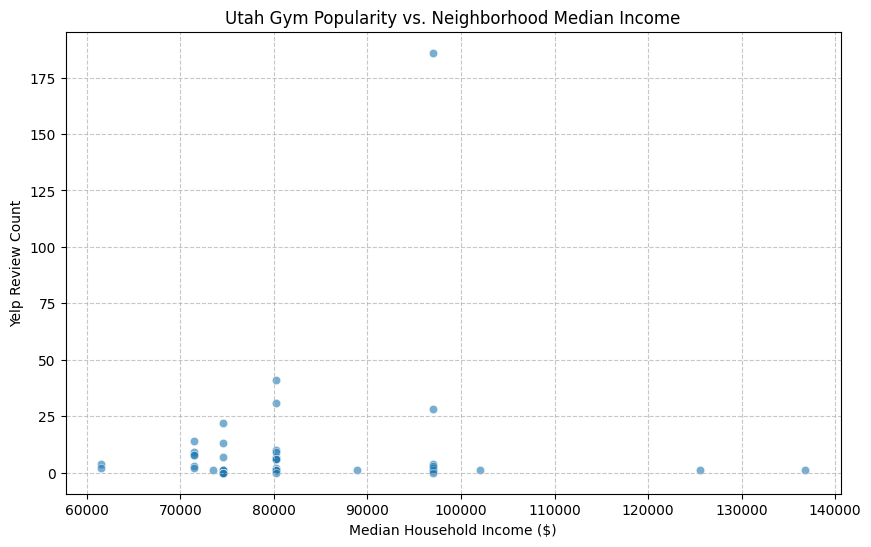

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Median Income and Gym Popularity (Review Count)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='median_income', y='review_count', alpha=0.6)
plt.title('Utah Gym Popularity vs. Neighborhood Median Income')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Yelp Review Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()